# US-07 - Gold WAE-GAN para Deteccao de Anomalias

**Objetivo:** Treinar a variante `WAEGAN` sobre as janelas normais (`P1`) e avaliar deteccao de anomalias no conjunto de teste completo.

**Entradas:** `data/processed/X_*.npy`, `y_*.npy` gerados no notebook de preprocessing.

**Convencao:** `0 = normal (P1)` e `1 = anomalia (P2/P3/P4)`.

## 1. Setup e Seeds

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_curve

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation import compute_anomaly_metrics
from src.models.wae_gan import WAEGAN, WAEGANConfig
from src.preprocessing import make_waegan_anomaly_splits

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project root:', PROJECT_ROOT)
print('Device:', DEVICE)
print('Torch:', torch.__version__)
if torch.cuda.is_available():
    print('CUDA:', torch.version.cuda)
    print('GPU:', torch.cuda.get_device_name(0))

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison
Device: cuda
Torch: 2.11.0+cu128
CUDA: 12.8
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


## 2. Carregar Dados

In [2]:
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'docs' / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)

X_train: (9720, 9, 4096) y_train: (9720,)
X_val:   (1944, 9, 4096) y_val:   (1944,)
X_test:  (2916, 9, 4096) y_test:  (2916,)


## 3. Hiperparametros

In [3]:
NORMAL_LABEL = 0

# Arquitetura
EMBEDDING_DIM = 32
ENCODER_LAYERS = 3
DROPOUT = 0.1
TCN_HIDDEN = 64
TCN_KERNEL = 3
DISC_HIDDEN = 32
DISC_LAYERS = 2
WAE_REG = 10.0
SIGMA_Z = 1.0

# Treino
LR = 1e-4
DISC_LR = 1e-4
DISC_STEPS = 1
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 5
MIN_DELTA = 0.0

# Avaliacao
THRESHOLD_MULTIPLIER = 1.5
CHECKPOINT_PATH = MODELS_DIR / 'wae_gan_best.pt'

print('EMBEDDING_DIM =', EMBEDDING_DIM)
print('ENCODER_LAYERS =', ENCODER_LAYERS)
print('TCN_HIDDEN =', TCN_HIDDEN)
print('TCN_KERNEL =', TCN_KERNEL)
print('DISC_HIDDEN =', DISC_HIDDEN)
print('DISC_LAYERS =', DISC_LAYERS)
print('WAE_REG =', WAE_REG)
print('SIGMA_Z =', SIGMA_Z)
print('LR =', LR)
print('DISC_LR =', DISC_LR)
print('BATCH_SIZE =', BATCH_SIZE)
print('EPOCHS =', EPOCHS)
print('PATIENCE =', PATIENCE)

EMBEDDING_DIM = 32
ENCODER_LAYERS = 3
TCN_HIDDEN = 64
TCN_KERNEL = 3
DISC_HIDDEN = 32
DISC_LAYERS = 2
WAE_REG = 10.0
SIGMA_Z = 1.0
LR = 0.0001
DISC_LR = 0.0001
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 5


## 4. Preparacao dos Splits de Anomalia

In [4]:
splits = make_waegan_anomaly_splits(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    normal_label=NORMAL_LABEL,
)

X_train_normal = splits['X_train_normal']
X_val_normal = splits['X_val_normal']
X_test_seq = splits['X_test']
y_test_binary = splits['y_test_binary']

print('X_train_normal:', X_train_normal.shape)
print('X_val_normal:  ', X_val_normal.shape)
print('X_test_seq:    ', X_test_seq.shape)
print('Anomalies in test:', int(y_test_binary.sum()), 'of', len(y_test_binary))

X_train_normal: (2430, 4096, 9)
X_val_normal:   (486, 4096, 9)
X_test_seq:     (2916, 4096, 9)
Anomalies in test: 2187 of 2916


## 5. Modelo

In [5]:
config = WAEGANConfig(
    n_features=X_train_normal.shape[2],
    embedding_dim=EMBEDDING_DIM,
    encoder_layers=ENCODER_LAYERS,
    dropout=DROPOUT,
    tcn_hidden=TCN_HIDDEN,
    tcn_kernel=TCN_KERNEL,
    disc_hidden=DISC_HIDDEN,
    disc_layers=DISC_LAYERS,
    lr=LR,
    disc_lr=DISC_LR,
    wae_regularization_term=WAE_REG,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    disc_steps=DISC_STEPS,
    sigma_z=SIGMA_Z,
    early_stopping_patience=PATIENCE,
    early_stopping_min_delta=MIN_DELTA,
    device=str(DEVICE),
)

model = WAEGAN(config)
n_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
print(model.model)
print('\nTrainable parameters:', f'{n_params:,}')

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


WAEGANCore(
  (encoder): Encoder_TCN(
    (tcn_layers): ModuleList(
      (0): TemporalBlock(
        (conv1): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (batch_norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(9, 64, kernel_size=(1,), stride=(1,))
      )
      (1): TemporalBlock(
        (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (batch_norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (batch_

## 6. Training Loop

In [6]:
t_start = time.time()
model.fit(train_data=X_train_normal, validation_data=X_val_normal, verbose=True)
train_time_s = time.time() - t_start

model.save(CHECKPOINT_PATH)

print('\nTraining time (s):', round(train_time_s, 2))
print('Best epoch:', model.best_epoch_)
print('Best monitor:', model.best_monitor_value_)
print('Stopped epoch:', model.stopped_epoch_)
print('Saved:', CHECKPOINT_PATH.relative_to(PROJECT_ROOT))

Epoch 1/50 | loss_D=1.398883 | loss_G=8.171402 | val_G=7.372685
Epoch 2/50 | loss_D=1.399109 | loss_G=7.537761 | val_G=7.185684
Epoch 3/50 | loss_D=1.393540 | loss_G=7.348249 | val_G=7.214893
Epoch 4/50 | loss_D=1.381680 | loss_G=7.390306 | val_G=7.244558
Epoch 5/50 | loss_D=1.383783 | loss_G=7.365693 | val_G=7.201989
Epoch 6/50 | loss_D=1.393096 | loss_G=7.308633 | val_G=7.172703
Epoch 7/50 | loss_D=1.391551 | loss_G=7.319325 | val_G=7.250141
Epoch 8/50 | loss_D=1.379764 | loss_G=7.403456 | val_G=7.299091
Epoch 9/50 | loss_D=1.380006 | loss_G=7.333432 | val_G=7.156281
Epoch 10/50 | loss_D=1.391918 | loss_G=7.159059 | val_G=6.982871
Epoch 11/50 | loss_D=1.400200 | loss_G=7.046076 | val_G=6.911481
Epoch 12/50 | loss_D=1.401670 | loss_G=7.026155 | val_G=6.947813
Epoch 13/50 | loss_D=1.394196 | loss_G=7.119217 | val_G=7.086040
Epoch 14/50 | loss_D=1.381275 | loss_G=7.269062 | val_G=7.220489
Epoch 15/50 | loss_D=1.379336 | loss_G=7.287084 | val_G=7.170711
Epoch 16/50 | loss_D=1.383005 | lo

## 7. Curvas de Treinamento

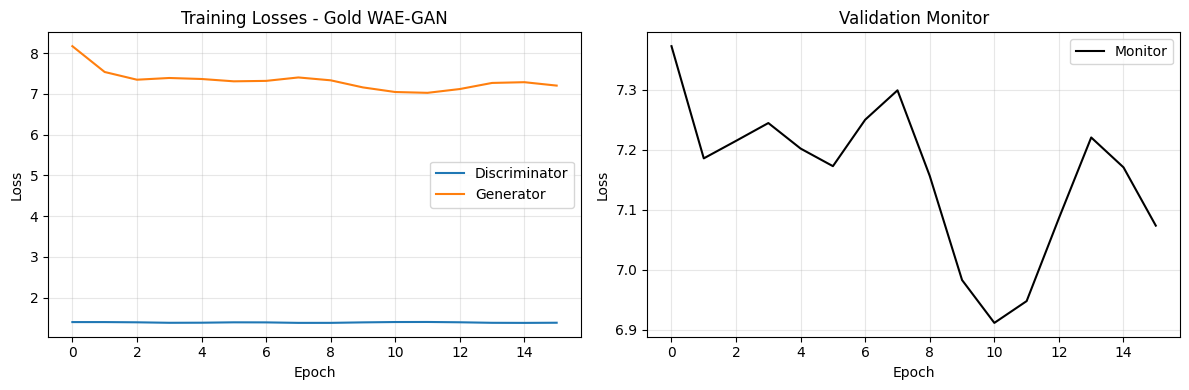

Saved: docs\figures\07_wae_gan_training_curves.png


In [7]:
history = model.history_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['discriminator'], label='Discriminator')
axes[0].plot(history['generator'], label='Generator')
axes[0].set_title('Training Losses - Gold WAE-GAN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['monitor'], color='black', label='Monitor')
axes[1].set_title('Validation Monitor')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '07_wae_gan_training_curves.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(PROJECT_ROOT))

## 8. Avaliacao no Conjunto de Teste

In [8]:
best_model = WAEGAN.load(CHECKPOINT_PATH, map_location=str(DEVICE))

train_scores = best_model.predict_anomaly_score(data=X_train_normal)
val_scores = best_model.predict_anomaly_score(data=X_val_normal)
test_scores = best_model.predict_anomaly_score(data=X_test_seq)

threshold = best_model.calculate_threshold(train_scores, multiplier=THRESHOLD_MULTIPLIER)
metrics = compute_anomaly_metrics(y_test_binary, test_scores, threshold=threshold)

print('Threshold:', threshold)
display(pd.Series(metrics).to_frame('value'))

Threshold: 0.3620072603225708


,value
auc_roc,0.999966
average_precision,0.999989
threshold,0.362007
accuracy,0.995885
precision,0.994993
recall,0.999543
f1,0.997263
tn,718.000000
fp,11.000000
fn,1.000000


## 9. Curva ROC e Distribuicao de Scores

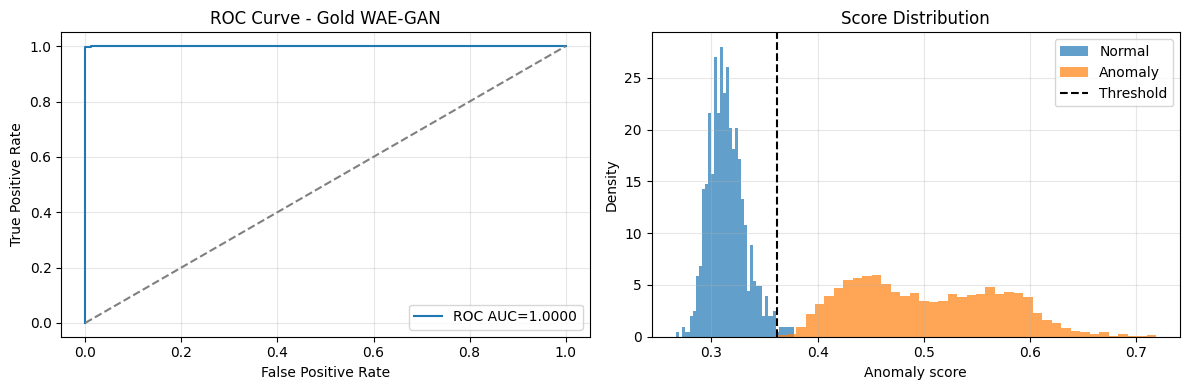

Saved: docs\figures\07_wae_gan_scores.png


In [9]:
fpr, tpr, _ = roc_curve(y_test_binary, test_scores)
normal_scores = test_scores[y_test_binary == 0]
anomaly_scores = test_scores[y_test_binary == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, label=f"ROC AUC={metrics['auc_roc']:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve - Gold WAE-GAN')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(normal_scores, bins=40, alpha=0.7, label='Normal', density=True)
axes[1].hist(anomaly_scores, bins=40, alpha=0.7, label='Anomaly', density=True)
axes[1].axvline(threshold, color='black', linestyle='--', label='Threshold')
axes[1].set_title('Score Distribution')
axes[1].set_xlabel('Anomaly score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '07_wae_gan_scores.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(PROJECT_ROOT))

## 10. Resumo

| Item | Valor |
|---|---|
| Modelo | WAE-GAN |
| Parametros treinaveis | `156170` |
| Tempo de treino | `134.82 s` |
| Melhor epoca | `11` |
| Threshold | `0.362007` |
| ROC-AUC | `0.999966` |
| Average Precision | `0.999989` |
| Accuracy | `0.995885` |
| F1 | `0.997263` |

**Artefatos gerados:**
- `models/wae_gan_best.pt`
- `docs/figures/07_wae_gan_training_curves.png`
- `docs/figures/07_wae_gan_scores.png`